Script to produce plots for averaged vortex rings for thesis chapter 6. These will be compared to the plots in chapter 5 that were not averages. I have made this script a copy of the other one but loading from h5 rather than individual files. U100 L00 was used in the other file.

The plots needed here are:
* line plots of velocity and vorticity
* contours of flow field
* quiver plots
* stream plots

Boilerplate code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
/Users/olliejackson/Coding
Thesis plot settings applied


Loading in the ring, scaling, and calculating variables from it.

In [2]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLS.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')

vels = h5file['Narrow']['U100']['L100']['RPM0']
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
# vels = h5file['Wide']['U200']['L100']['RPM0']

u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()

u, v = oj.scaleVelNozzle(u, v, 90)
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])

Time = oj.frames_to_seconds(u, v, 90)
vort, vort_gauss = oj.calculate_vorticity(u, v)

Contour of flow field plots
* u
* v
* $\omega$

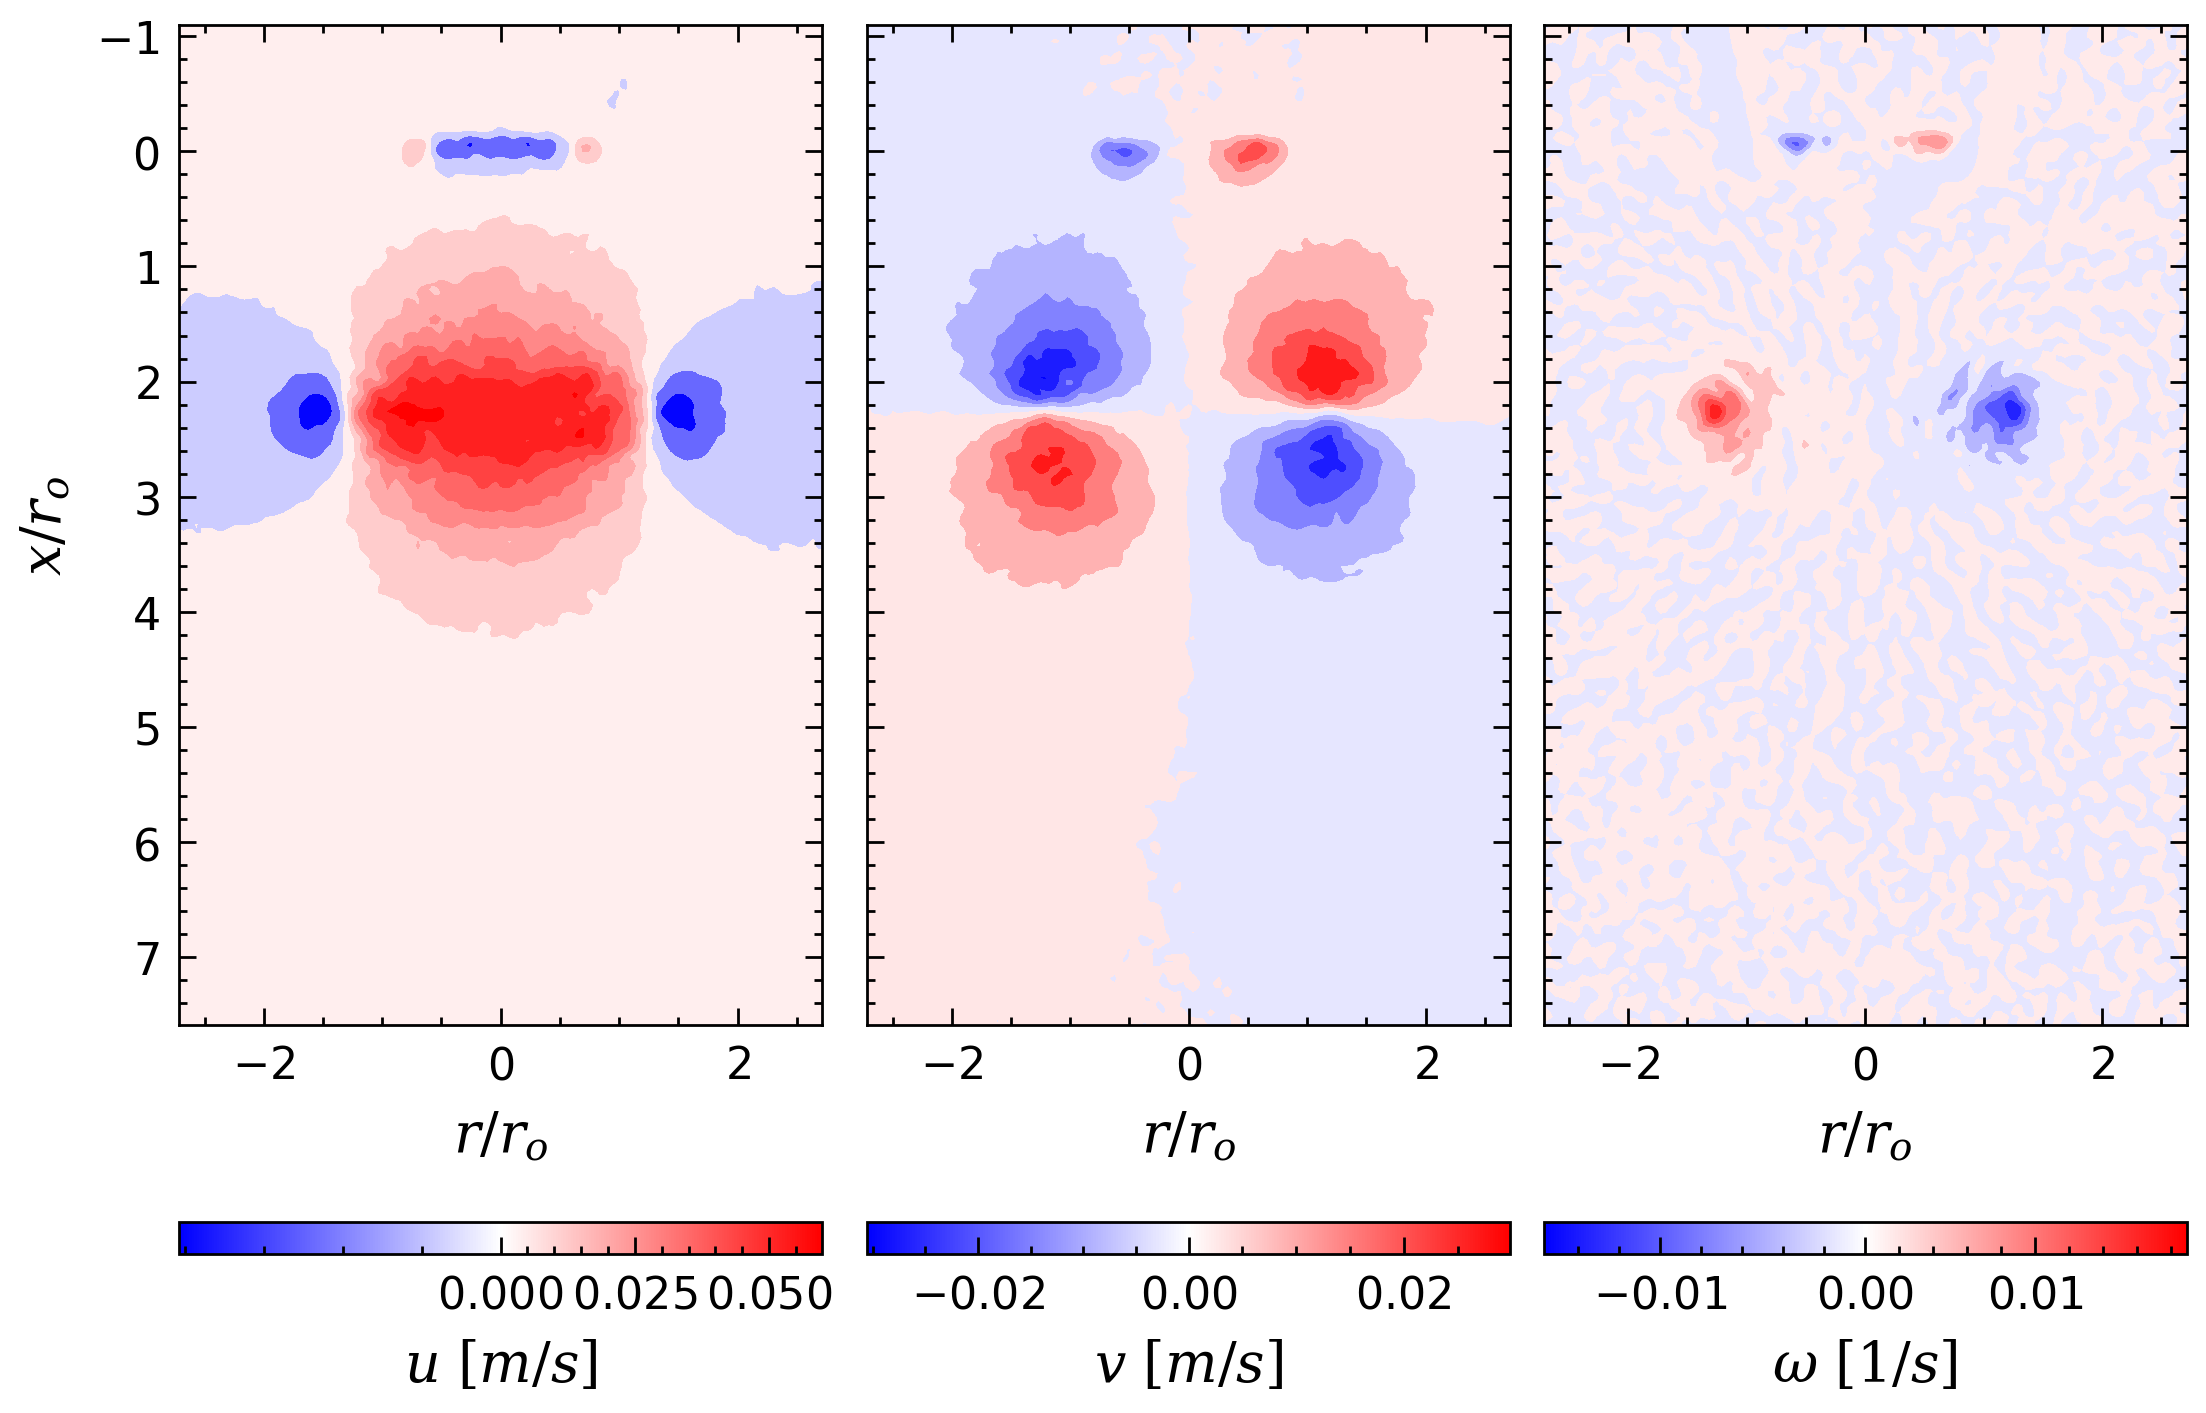

In [3]:
# norm = colors.TwoSlopeNorm(vmin=np.min(u[300, :, :]), vcenter=0, vmax=np.max(u[300, :, :]))
# fig, ax = plt.subplots(1, 1)
# ax.contourf(r_nd, -z_nd, np.rot90(u[300, :, :], 3), norm=norm, cmap='bwr', levels=10)
# fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax, label=r'$u$' )
# plt.show()

unorm = colors.TwoSlopeNorm(vmin=np.min(u[300, :, :]), vcenter=0, vmax=np.max(u[300, :, :]))
vnorm = colors.TwoSlopeNorm(vmin=np.min(v[300, :, :]), vcenter=0, vmax=np.max(v[300, :, :]))
onorm = colors.TwoSlopeNorm(vmin=np.min(vort[300, :, :]), vcenter=0, vmax=np.max(vort[300, :, :]))


f1, axs = plt.subplots(1, 3, figsize=(5.5, 3.5), layout='constrained')
axs[0].set_ylim(z_nd.max(), z_nd.min())
axs[0].contourf(r_nd, z_nd, np.rot90(u[300, :, :], 3), norm=unorm, cmap='bwr', levels=10)
axs[0].set_xlabel(r"$r/r_{o}$")
axs[0].set_ylabel(r"$x/r_{o}$")
f1.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=axs[0], label=r'$u ~[m/s]$', location='bottom')
axs[1].contourf(r_nd, -z_nd, np.rot90(v[300, :, :], 3), norm=vnorm, cmap='bwr', levels=10)
axs[1].set_xlabel(r"$r/r_{o}$")
axs[1].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=axs[1], label=r'$v ~[m/s]$', location='bottom')
axs[2].contourf(r_nd, -z_nd, np.rot90(vort_gauss[300, :, :], 3), norm=onorm, cmap='bwr', levels=10)
axs[2].set_xlabel(r"$r/r_{o}$")
axs[2].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=axs[2], label=r'$\omega ~[1/s]$', location='bottom')
plt.show()

Line Plot through the ring at a single time:

Showing:
* u
* v
* $\omega$

/var/folders/3b/wm5n0kv12hbfldn7fhkv1d280000gn/T/ipykernel_49401/2096584009.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


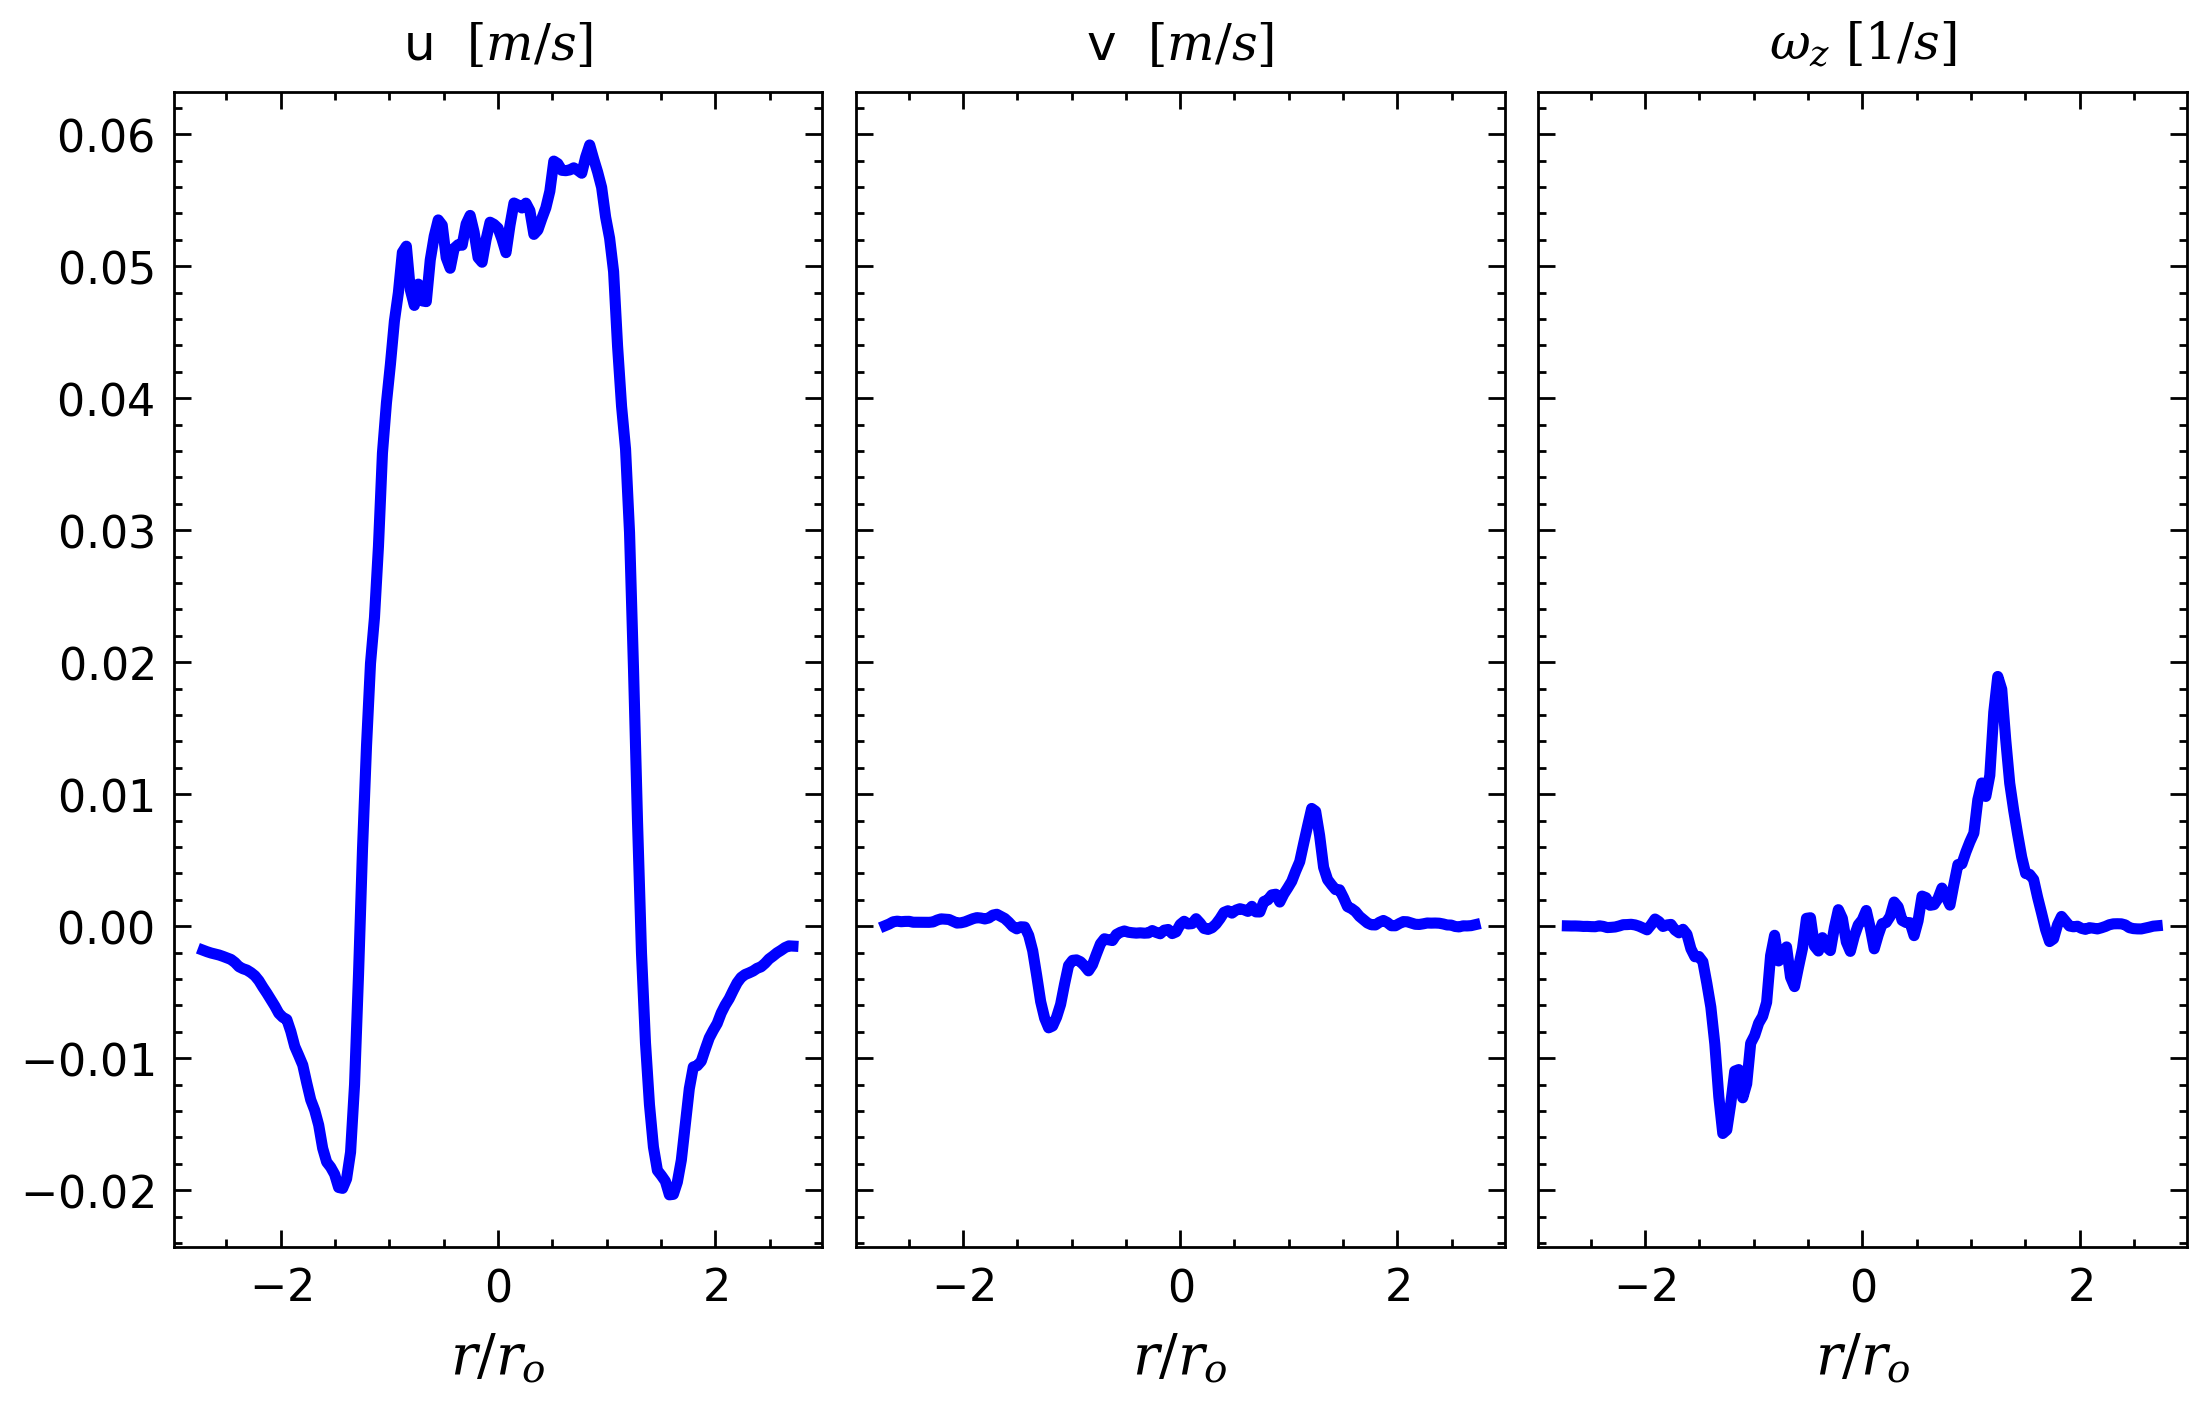

In [4]:
vort_loc_min, vort_loc_max = oj.vorticityPeakTracking(u, v)

frame = 300

zLocation = int(np.mean([vort_loc_min[frame,1], vort_loc_max[frame,1]], axis=0) )
# print(zLocation)
# print(vort_loc_min[frame,1])
# print(vort_loc_max[frame,1])

# fig, ax = plt.subplots(1, 1)
# ax.plot(vort_loc_max[:,1], label="Max Vorticity")
# ax.plot(vort_loc_min[:,1], label="Min Vorticity")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Vorticity (1/s)")
# plt.legend()
# plt.show()

####### Unfiltered Plots
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(5.5, 3.5), layout='constrained')
ax[0].set_title(r'u $~[m/s]$', fontsize=9)
ax[0].plot(r_nd, u   [frame,:,zLocation], color = 'b')
ax[0].set_xlabel(r"$r/r_{o}$")
ax[1].set_title(r'v $~[m/s]$', fontsize=9)
ax[1].plot(r_nd, v   [frame,:,zLocation+1], color = 'b')
ax[1].set_xlabel(r"$r/r_{o}$")
ax[2].set_title(r'$\omega_{z} ~[1/s]$', fontsize=9)
ax[2].plot(r_nd, vort[frame,:,zLocation], color = 'b')
ax[2].set_xlabel(r"$r/r_{o}$")
ax[2].legend()
plt.show()

####### Gaussian Filtered Plots
# from scipy.ndimage import gaussian_filter
# sigma = 2
# ugauss, vgauss, vort_gauss = gaussian_filter(u, sigma=sigma), gaussian_filter(v, sigma=sigma), gaussian_filter(vort, sigma=sigma)
# fig, ax = plt.subplots(1, 3, sharex=True, figsize=(5.5, 3.5), layout='constrained')
# ax[0].set_title('u ~[m/s]', fontsize=9)
# ax[0].plot(r_nd, ugauss   [frame,:,zLocation], color = 'b')
# ax[1].set_title('v ~[m/s]', fontsize=9)
# ax[1].plot(r_nd, vgauss   [frame,:,zLocation+1], color = 'b')
# ax[2].set_title(r'$\omega_{z} ~[1/s]$', fontsize=9)
# ax[2].plot(r_nd, vort_gauss[frame,:,zLocation], color = 'b')
# ax[2].legend()
# plt.show()

Quiver Plot - need to load in the coarse data for this one

/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/matplotlib/patches.py:3421: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


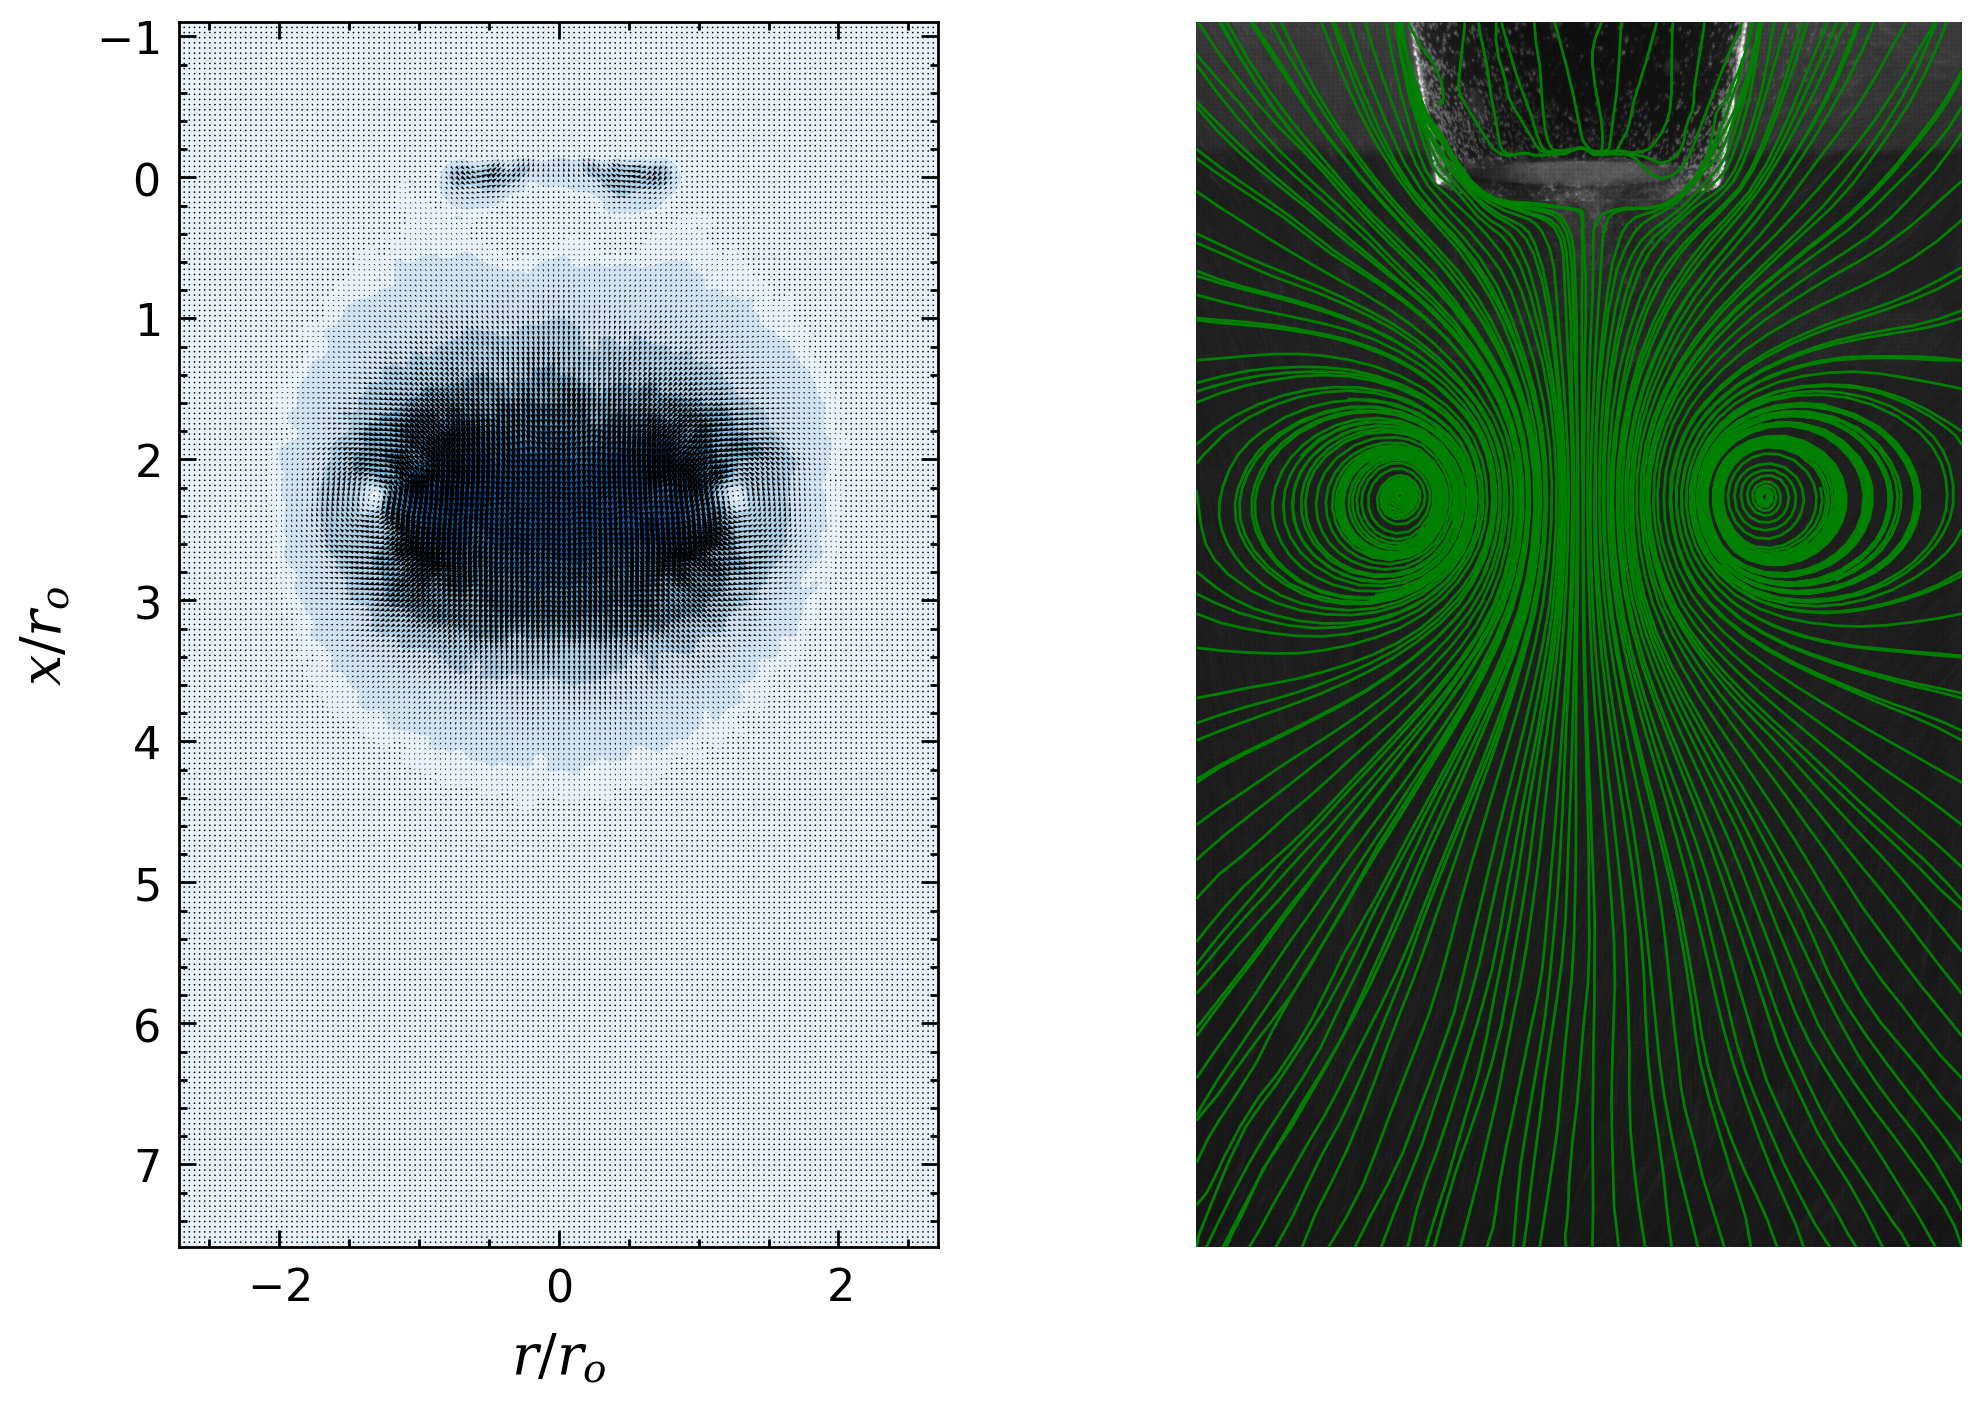

In [5]:
# dir = 'G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/'

# u, v = oj.importData73(str(dir) + "3/Data/PIV_export.mat")
# u, v = oj.scaleVelNozzle(u, v, 90)
# r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])

V = np.sqrt(u**2 + v**2)
# norm = colors.TwoSlopeNorm(vmin=0, vcenter=np.max(V[frame, :, :])/2, vmax=np.max(V[frame, :, :]))

# fig, ax = plt.subplots(1, 1, sharex=True, figsize=(2.5, 3.5), layout='constrained')
# ax.contourf(r_nd, -z_nd, np.rot90(V[frame, :, :], 3), cmap='Blues')
# ax.quiver(r_nd, -z_nd, np.rot90(-v[frame, :, :], 3), np.rot90(-u[frame, :, :], 3))
# ax.set_xlabel(r"$r/r_{o}$")
# ax.set_ylabel(r"$z/r_{o}$")
# fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='Blues'), ax=ax, label=r'$V ~[m/s]$', location='bottom')
# plt.show()


z_nd_star = z_nd - 0.55

# im = plt.imread('C:/Users/u2088308/Pictures/image1_bg_rot.tiff')
im = plt.imread('/Volumes/HLS_0D0/image1_bg_rot.tiff')
f1, axs = plt.subplots(1, 2, figsize=(5.5, 3.5), layout='constrained', gridspec_kw={'width_ratios': [1, 1.6]})
# f1.tight_layout()
axs[0].set_ylim(z_nd.max(), z_nd.min())
axs[0].contourf(r_nd, z_nd, np.rot90(V[frame, :, :], 3), cmap='Blues')
axs[0].quiver(r_nd, z_nd, np.rot90(-v[frame, :, :], 3), np.rot90(-u[frame, :, :], 3))
axs[0].set_xlabel(r"$r/r_{o}$")
axs[0].set_ylabel(r"$x/r_{o}$")
# fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='Blues'), ax=axs[0], label=r'$V ~[m/s]$', location='bottom')

axs[1].axis("off")
axs[1].imshow(im,extent=[ r_nd[0], r_nd[-1], z_nd_star[0], z_nd_star[-1],], cmap = 'Greys_r')
axs[1].streamplot(r_nd, z_nd_star, np.rot90(-v[frame,:,:],1), np.rot90(u[frame,:,:],1),  color = 'g', broken_streamlines = False, arrowsize=0, linewidth=0.5)#, color=V[:,:])
# axs[1].streamplot(r_nd, z_nd, v[frame, :, :], u[frame, :, :])
axs[1].set_ylim([z_nd_star[0], z_nd_star[-1]])
axs[1].set_xlim([r_nd[0], r_nd[-1]])
axs[1].grid(False)
# f3.savefig('//cantus.ads.warwick.ac.uk/User44/u/u2088308/Documents/My Pictures/Gift_images/0stream.png', dpi = 400)
plt.show()